In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from IPython.display import display

from sklearn import metrics

# versions
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"tensorflow: {tf.__version__}")

numpy: 2.4.6
pandas: 3.0.3
seaborn: 0.13.2
tensorflow: 2.21.0


In [54]:
data_path = Path("../Finalized_Feature_Sets/model_data_simple.parquet")

model_data_simple = pd.read_parquet(
    data_path,
    engine="pyarrow"
)

model_data_simple.shape

(1700, 31)

In [55]:
feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"]

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"]

# Naive Baseline Model: Majority Class

* only uses the training data to determine the majority class and predicts that for all instances in the test set
* serves as a baseline to compare the performance of more complex models; logistic regression usually is the benchmark after the majority class model
* is a deterministic model (does not involve any randomness in its predictions) and as such does not require a random seed for reproducibility

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


# -----------------------------
# 2. Majority class naive model
# -----------------------------

majority_model = DummyClassifier(strategy="most_frequent")

majority_model.fit(x_train, y_train)

y_pred = majority_model.predict(x_test)
y_prob = majority_model.predict_proba(x_test)[:, 1]


# -----------------------------
# 3. Evaluate performance
# -----------------------------

print("Majority class predicted:", majority_model.classes_[majority_model.class_prior_.argmax()])

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Majority class predicted: 0
Accuracy: 0.7464788732394366
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.5
PR AUC: 0.2535211267605634

Confusion Matrix:
[[318   0]
 [108   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.85       318
           1       0.00      0.00      0.00       108

    accuracy                           0.75       426
   macro avg       0.37      0.50      0.43       426
weighted avg       0.56      0.75      0.64       426



"Majority Class predicted: 0" means no myocardial infarction (MI) predicted for all patients in the test set, which is the majority class in the training data. This model will have high accuracy if the majority class is dominant

# Calculating Metrics for Logistic Regression: 
* logistic regression was already trained and evaluated but it is calculated here to standardize metrics for comparison

In [60]:
x_train = pd.get_dummies(x_train, drop_first=False)
x_test = pd.get_dummies(x_test, drop_first=False)

x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

print(set(x_train.columns) - set(x_test.columns))  # should be empty set
print(x_train.shape)
print(x_test.shape)

set()
(1274, 46)
(426, 46)


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# -----------------------------
# 3. Standardize predictors
# -----------------------------

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# -----------------------------
# 4. Logistic regression model
# -----------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=321
)

logistic_model.fit(x_train_scaled, y_train)

y_pred = logistic_model.predict(x_test_scaled)
y_prob = logistic_model.predict_proba(x_test_scaled)[:, 1]


# -----------------------------
# 5. Evaluate performance
# -----------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8028169014084507
Precision: 0.875
Recall: 0.25925925925925924
F1: 0.4
ROC AUC: 0.7230375029117168
PR AUC: 0.5661060912059517

Confusion Matrix:
[[314   4]
 [ 80  28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.88       318
           1       0.88      0.26      0.40       108

    accuracy                           0.80       426
   macro avg       0.84      0.62      0.64       426
weighted avg       0.82      0.80      0.76       426



# Simple MLP Model

* requires purely numeric features
* some form of normalization or standardization is typically needed for MLPs to perform well, especially if the features are on different scales
    * e.g. standardization (z-score normalization), min-max normalization or unit-norm normalization

In [62]:
# One-hot encode categorical predictors

x_train = pd.get_dummies(x_train, drop_first=False)
x_test = pd.get_dummies(x_test, drop_first=False)

x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

print(set(x_train.columns) - set(x_test.columns))  # should be empty set
print(x_train.shape)
print(x_test.shape)

set()
(1274, 46)
(426, 46)


In [63]:
# standardscalar is a common choice for MLPs, especially when features are on different scales
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [64]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=321
)

mlp_model.fit(x_train_scaled, y_train)

/home/Max_Vo/anaconda3/envs/Deep_ML/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",321


In [65]:
print(x_train_scaled.shape)
print(x_test_scaled.shape)
print(y_train.sum(), y_test.sum())

(1274, 46)
(426, 46)
286 108


In [66]:
print("Input features:", mlp_model.n_features_in_)
print("Hidden layers:", mlp_model.hidden_layer_sizes)
print("Output classes:", mlp_model.n_outputs_)

Input features: 46
Hidden layers: (16,)
Output classes: 1


In [67]:
y_pred = mlp_model.predict(x_test_scaled)
y_prob = mlp_model.predict_proba(x_test_scaled)[:, 1]

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7183098591549296
Precision: 0.43617021276595747
Recall: 0.37962962962962965
F1: 0.40594059405940597
ROC AUC: 0.6044432797577451
PR AUC: 0.4264220140073839

Confusion Matrix:
[[265  53]
 [ 67  41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       318
           1       0.44      0.38      0.41       108

    accuracy                           0.72       426
   macro avg       0.62      0.61      0.61       426
weighted avg       0.71      0.72      0.71       426



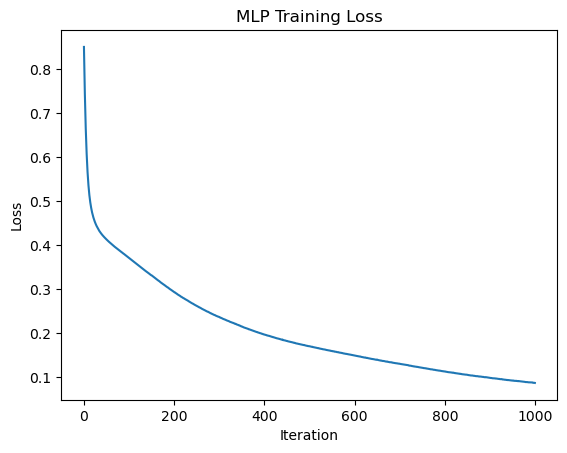

In [71]:
import matplotlib.pyplot as plt

plt.plot(mlp_model.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.show()

In [73]:
print(x_train.shape)

(1274, 46)
